<a target="_blank" href="https://colab.research.google.com/github/bmalcover/AppOC/blob/main/docs/notebooks/04_Images/03_Detection_segmentation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Other tasks

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Metrics](#metrics)
2. [Object detection](#im_mod)
3. [Segmentation](#tra_lr)

While **image classification** assigns a single label to an entire image, there are many other important computer vision tasks that go beyond simply identifying what an image contains:

<img src="../../_static/04/diff.jpg" width="500" />

### Object Detection
Object detection identifies **multiple objects** within an image and locates them by drawing **bounding boxes** around each object. Each box is labeled with the detected class and often includes a **confidence score**. This is essential for applications like:
- Autonomous driving (detecting pedestrians, vehicles, traffic signs)
- Security systems (detecting people, suspicious objects)
- Retail analytics (counting products on shelves)

### Image Segmentation
Image segmentation assigns a **class label to every pixel** in an image, creating a detailed **pixel-level mask**. Unlike detection which uses bounding boxes, segmentation provides precise object boundaries. Two main approaches:
- **Semantic Segmentation**: All pixels of the same class have the same label (e.g., all dogs are one color)
- **Instance Segmentation**: Different instances of the same class have different labels (e.g., each dog separately)

Segmentation is used in:
- Medical imaging (identifying tumors, organs)
- Satellite imagery (land use classification)
- Autonomous vehicles (road/obstacle/lane detection)

In this notebook, we'll explore techniques and models for both detection and segmentation tasks.

<div class="alert alert-warning">
    <b> I. <i>Evaluation Metrics</i></b>
    <a id="metrics"></a>
</div>


The measures used until know are not working for these kind of tasks. Therefore, we need a measure for these scenarios. The main evluation metric for object detection and segmentation is Intersection over Union (IoU). Measures the overlap between predicted and ground truth bounding boxes. A detection is considered correct if IoU is greater than a threshold (commonly 0.5). 


<img src="../../_static/04/iou.png" width="500" />


**Definition:**
$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}} = \frac{I}{U}$$

Where:
- **Intersection (I)**: The overlapping area between the predicted box and the ground truth box
- **Union (U)**: The total area covered by both boxes (without double-counting the intersection)

**IoU Range:**
- **IoU = 0**: No overlap - completely missed prediction
- **IoU = 1**: Perfect match - predicted box exactly matches ground truth
- **IoU ∈ [0, 1]**: Partial overlap - the closer to 1, the better the prediction

**Practical Thresholds:**
- **IoU > 0.5**: Often used as the minimum threshold to consider a detection as "correct"
- **IoU > 0.75**: Stricter threshold for high-quality detections
- **IoU > 0.9**: Very stringent threshold for near-perfect predictions

**Why IoU is Important:**
1. **Localization Accuracy**: Unlike classification (which only cares about the class), IoU evaluates how precisely the model localized the object
2. **Threshold Flexibility**: Different applications require different IoU thresholds (autonomous driving needs higher precision than web image tagging)
3. **Dataset Independence**: The metric doesn't depend on dataset-specific properties; it's universally applicable



<div class="alert alert-warning">
    <b> II. <i>Object detection</i></b>
    <a id="metrics"></a>
</div>

**YOLO (You Only Look Once)** is a real-time object detection framework that revolutionized how computers detect objects in images and videos. Instead of scanning multiple regions, YOLO predicts bounding boxes and class probabilities in a **single forward pass**, making it extremely efficient.

**Ultralytics** is the official organization maintaining and developing YOLO. They provide the `ultralytics` Python library, which offers:

- **State-of-the-art Models**: YOLOv8, YOLOv9, YOLOn, and other versions optimized for different use cases
- **Multiple Tasks**: 
  - Object detection
  - Instance segmentation
  - Pose estimation
  - Multi-object tracking
  - Classification

**Key Advantages of Ultralytics YOLO:**

1. **Speed**: Real-time inference on CPUs, GPUs, and mobile devices
2. **Accuracy**: Competitive mAP scores on standard benchmarks (COCO, Pascal VOC)
3. **Ease of Use**: Simple API for training, inference, and evaluation
4. **Pre-trained Weights**: Models come pre-trained on COCO (80 classes) or other datasets
5. **Transfer Learning**: Easy fine-tuning on custom datasets
6. **Deployment**: Supports export to various formats (ONNX, TensorRT, CoreML, etc.)

**YOLO Workflow:**

1. **Load a Pre-trained Model**: Automatically downloads weights from HuggingFace
2. **Predict on Images/Videos**: Apply detection in one line of code
3. **Fine-tune on Custom Data**: Train with custom labeled datasets
4. **Deploy**: Export to production-ready formats

This makes YOLO ideal for practical computer vision applications, from autonomous driving to real-time video analysis. 

First we need to install the library:

In [2]:
!pip install ultralytics

Ultralythic allow us to load images with many different ways. The most straightforward approach is the to first load the image, and then make the prediction.

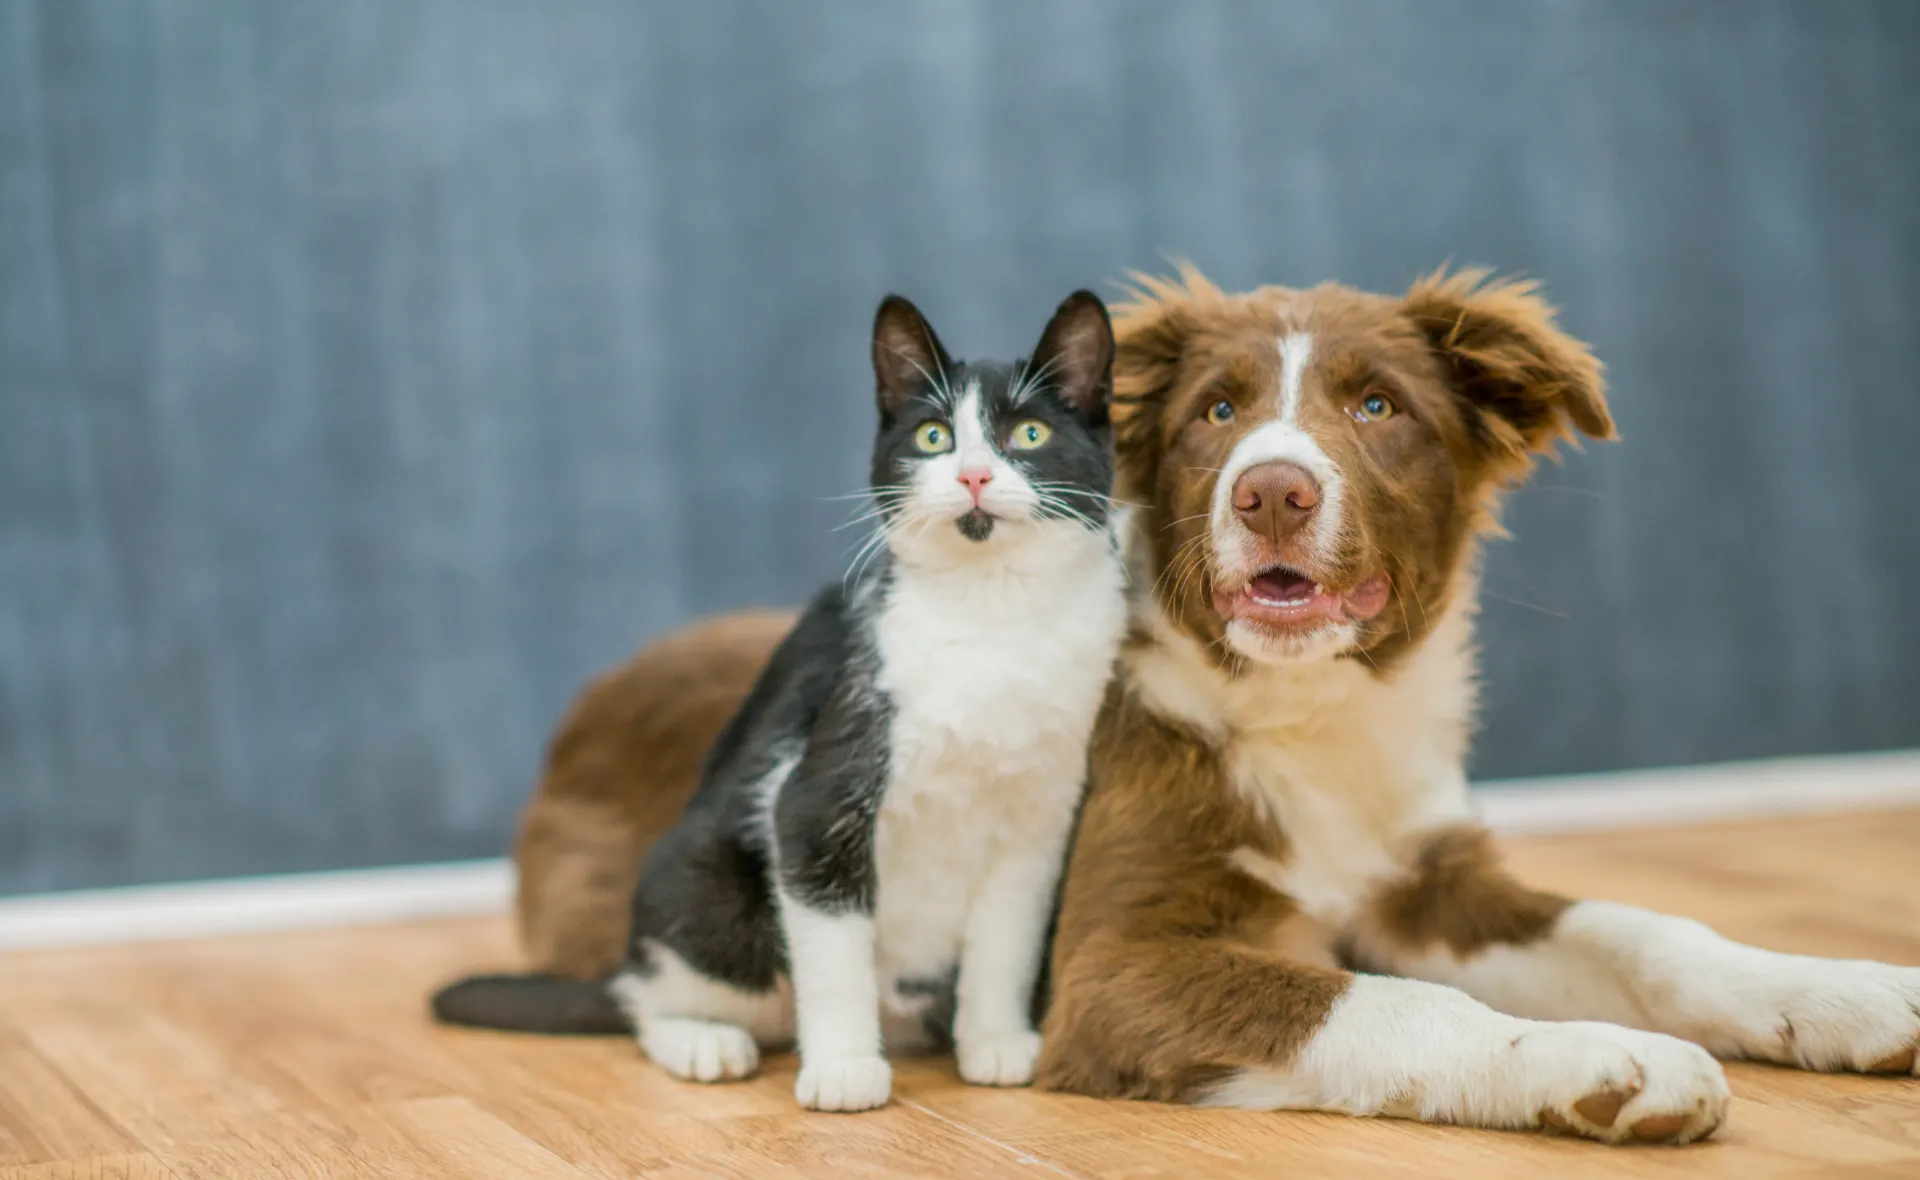

In [3]:
from PIL import Image

img = Image.open('./data/example.jpg')
img

In [4]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model (automatically downloads weights)
# Available sizes: nano (n), small (s), medium (m), large (l), extra-large (x)
model = YOLO('yolov8m.pt')  # Medium model, good balance between speed and accuracy

# Predict on an image
#results = model.predict(source='./data/example.jpg', conf=0.5)
results = model.predict(source=img, conf=0.5)

# Access detection results
for result in results:
    boxes = result.boxes  # Bounding boxes
    print(f"Detections: {len(boxes)}")
    
    for box in boxes:
        # Get coordinates and confidence
        x1, y1, x2, y2 = box.xyxy[0]
        conf = box.conf[0]
        cls = box.cls[0]
        print(f"Class: {cls}, Confidence: {conf:.2f}, Box: ({x1}, {y1}, {x2}, {y2})")


0: 416x640 1 cat, 1 dog, 92.9ms
Speed: 4.0ms preprocess, 92.9ms inference, 4.7ms postprocess per image at shape (1, 3, 416, 640)
Detections: 2
Class: 15.0, Confidence: 0.94, Box: (425.8559265136719, 287.2218017578125, 1129.8370361328125, 1115.449951171875)
Class: 16.0, Confidence: 0.94, Box: (1030.36279296875, 257.534912109375, 1918.24560546875, 1147.1893310546875)


In [5]:
result.show()  # display to screen

<div class="alert alert-warning">
    <b> III. <i>Segmentation</i></b>
    <a id="tra_lr"></a>
</div>

**Image Segmentation** is a computer vision task that assigns a class label to **every pixel** in an image, creating a detailed pixel-level mask. Unlike object detection which provides bounding boxes, segmentation delivers precise object boundaries and is essential for applications requiring precise localization.

**Two Main Types of Segmentation:**

1. **Semantic Segmentation**: Assigns the same label to all pixels of the same class
   - Example: All pixels belonging to dogs get one label, all cars get another
   - Doesn't distinguish between different instances of the same class
   - Use cases: Medical imaging, satellite imagery, autonomous driving

2. **Instance Segmentation**: Assigns different labels to different instances of the same class
   - Example: Each dog in the image gets its own unique label
   - Combines the strengths of object detection and semantic segmentation
   - Use cases: Counting individual objects, tracking multiple instances

**Advantages of Segmentation over Detection:**
- **Precise Boundaries**: Pixel-level accuracy instead of bounding boxes
- **Better Localization**: Exact shape and size of objects
- **Context Understanding**: Useful for scene understanding and analysis

**YOLO for Segmentation:**

The ultralytics YOLO framework supports **instance segmentation** out of the box. The workflow is similar to object detection, but the output includes:
- Bounding boxes (same as detection)
- Confidence scores
- **Segmentation masks** (polygon points or binary masks for each detected object)

This allows you to get both detection and precise segmentation in a single pass, making it ideal for real-world applications that require both speed and accuracy.

### Instance Segmentation with YOLO

To perform instance segmentation, we use a YOLO segmentation model (note the difference from detection models). The model automatically detects objects **and** provides segmentation masks for each instance:


In [7]:
# Load a pre-trained YOLOv8 segmentation model
# Note: Using 'seg' in the model name loads a segmentation-capable model
model_seg = YOLO('yolov8m-seg.pt')  # Segmentation model

# Perform instance segmentation
seg_results = model_seg.predict(source=seg_img, conf=0.5)

# Access segmentation results
for result in seg_results:
    masks = result.masks  # Segmentation masks
    boxes = result.boxes  # Bounding boxes
    
    print(f"Total instances detected: {len(boxes)}")
    
    if masks is not None:
        print(f"Segmentation masks shape: {masks.shape}")
        print(f"Mask data type: {masks.data.dtype}")
        
        for i, box in enumerate(boxes):
            # Get detection info
            x1, y1, x2, y2 = box.xyxy[0]
            conf = box.conf[0]
            cls = box.cls[0]
            
            # Get segmentation mask
            mask = masks.data[i]  # Binary mask for this instance
            pixels_in_mask = mask.sum().item()
            
            print(f"\nInstance {i}:")
            print(f"  Class: {int(cls)}, Confidence: {conf:.2f}")
            print(f"  Box: ({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")
            print(f"  Mask pixels: {pixels_in_mask:.0f}")



0: 416x640 1 cat, 1 dog, 115.2ms
Speed: 1.3ms preprocess, 115.2ms inference, 2.6ms postprocess per image at shape (1, 3, 416, 640)
Total instances detected: 2
Segmentation masks shape: torch.Size([2, 416, 640])
Mask data type: torch.uint8

Instance 0:
  Class: 16, Confidence: 0.88
  Box: (1029, 256, 1917, 1144)
  Mask pixels: 47706

Instance 1:
  Class: 15, Confidence: 0.71
  Box: (576, 288, 1129, 1116)
  Mask pixels: 31239


In [8]:
seg_result = seg_results[0]
seg_result.show()  # Display segmentation results with masks overlaid


## Exercice

1. Load an image and do an object detection and segmentation with ultralytics.
2. How would you obtain the IOU for both tasks?